In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import time
from collections import deque
import threading
from IPython.display import display, clear_output
import ipywidgets as widgets
from matplotlib.animation import FuncAnimation
import warnings
warnings.filterwarnings('ignore')

# Import your custom modules (adjust paths as needed)
import sys
sys.path.append('..')  # Adjust this path to your src directory

from src.models.mediapipe_model import MediaPipeModel
from src.models.movenet_model import MoveNetModel
from src.analyzers.rep_counter import RepCounter
from src.analyzers.form_analyzer import FormAnalyzer
from src.utils.visualization import PoseVisualizer

print("All imports successful!")
print("Make sure your webcam is connected and accessible")


All imports successful!
Make sure your webcam is connected and accessible


In [2]:
class RealTimePoseTester:
    def __init__(self, exercise_type='squat'):
        self.exercise_type = exercise_type
        self.running = False
        
        # Initialize models
        print("Loading MediaPipe model...")
        self.mediapipe_model = MediaPipeModel(
            complexity=1,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        
        print("Loading MoveNet Lightning model...")
        self.movenet_model = MoveNetModel('lightning')
        
        print("Loading MoveNet Thunder model...")
        self.movenet_thunder = MoveNetModel('thunder')
        
        # Initialize analyzers
        self.rep_counters = {
            'mediapipe': RepCounter(exercise_type),
            'movenet_lightning': RepCounter(exercise_type),
            'movenet_thunder': RepCounter(exercise_type)
        }
        
        self.form_analyzers = {
            'mediapipe': FormAnalyzer(exercise_type),
            'movenet_lightning': FormAnalyzer(exercise_type),
            'movenet_thunder': FormAnalyzer(exercise_type)
        }
        
        # Initialize visualizer
        self.visualizer = PoseVisualizer()
        
        # Data storage for analysis
        self.frame_data = {
            'mediapipe': [],
            'movenet_lightning': [],
            'movenet_thunder': []
        }
        
        self.angle_history = {
            'mediapipe': deque(maxlen=300),  # 10 seconds at 30fps
            'movenet_lightning': deque(maxlen=300),
            'movenet_thunder': deque(maxlen=300)
        }
        
        print("All models and analyzers loaded successfully!")
        
    def validate_squat_algorithm(self):
        """Validate that squat uses knee-based angles"""
        print("\nValidating Squat Algorithm Configuration:")
        
        for model_name, rep_counter in self.rep_counters.items():
            config = rep_counter.exercise_configs['squat']
            print(f"\n{model_name.upper()}:")
            print(f"  Primary angle: {config['primary_angle']}")
            print(f"  Secondary angle: {config['secondary_angle']}")
            print(f"  Down threshold: {config['down_threshold']}°")
            print(f"  Up threshold: {config['up_threshold']}°")
            print(f"  Min range: {config['min_range']}°")

# Initialize the tester
tester = RealTimePoseTester('squat')
tester.validate_squat_algorithm()

Loading MediaPipe model...
Loading MoveNet Lightning model...
Loading MoveNet lightning model...



MoveNet lightning loaded successfully!
Loading MoveNet Thunder model...
Loading MoveNet thunder model...
MoveNet thunder loaded successfully!
All models and analyzers loaded successfully!

Validating Squat Algorithm Configuration:

MEDIAPIPE:
  Primary angle: knee
  Secondary angle: hip
  Down threshold: 100°
  Up threshold: 150°
  Min range: 30°

MOVENET_LIGHTNING:
  Primary angle: knee
  Secondary angle: hip
  Down threshold: 100°
  Up threshold: 150°
  Min range: 30°

MOVENET_THUNDER:
  Primary angle: knee
  Secondary angle: hip
  Down threshold: 100°
  Up threshold: 150°
  Min range: 30°


In [3]:
def process_frame_with_all_models(frame, tester):
    """Process frame with all models and return results"""
    results = {}
    
    # Process with MediaPipe
    mp_result = tester.mediapipe_model.process_frame(frame)
    mp_keypoints = MediaPipeModel.mediapipe_to_coco_format(mp_result['keypoints'])
    
    # Process with MoveNet Lightning
    ml_result = tester.movenet_model.process_frame(frame)
    ml_keypoints = ml_result['keypoints']
    
    # Process with MoveNet Thunder
    mt_result = tester.movenet_thunder.process_frame(frame)
    mt_keypoints = mt_result['keypoints']
    
    # Store results
    results = {
        'mediapipe': {
            'keypoints': mp_keypoints,
            'processing_time': mp_result['processing_time'],
            'fps': 1.0 / mp_result['processing_time'] if mp_result['processing_time'] > 0 else 0,
            'raw_result': mp_result
        },
        'movenet_lightning': {
            'keypoints': ml_keypoints,
            'processing_time': ml_result['processing_time'],
            'fps': 1.0 / ml_result['processing_time'] if ml_result['processing_time'] > 0 else 0,
            'raw_result': ml_result
        },
        'movenet_thunder': {
            'keypoints': mt_keypoints,
            'processing_time': mt_result['processing_time'],
            'fps': 1.0 / mt_result['processing_time'] if mt_result['processing_time'] > 0 else 0,
            'raw_result': mt_result
        }
    }
    
    return results

def analyze_poses(results, tester, frame_num):
    """Analyze poses with rep counters and form analyzers"""
    analysis_results = {}
    
    for model_name, result in results.items():
        keypoints = result['keypoints']
        
        if keypoints.shape[0] > 0 and keypoints[0].sum() > 0:  # Check if person detected
            # Rep counting
            rep_result = tester.rep_counters[model_name].process_frame(
                keypoints[0], frame_num
            )
            
            # Form analysis
            form_faults = tester.form_analyzers[model_name].analyze_form(
                keypoints[0], rep_result['current_state']
            )
            
            # Store angle history with performance metrics
            if 'primary_angle' in rep_result:
                tester.angle_history[model_name].append({
                    'frame': frame_num,
                    'angle': rep_result['primary_angle'],
                    'smoothed_angle': rep_result.get('smoothed_angle', rep_result['primary_angle']),
                    'state': rep_result['current_state'],
                    'confidence': rep_result['confidence'],
                    'processing_time': result['processing_time'],
                    'fps': result['fps']
                })
            
            analysis_results[model_name] = {
                'rep_result': rep_result,
                'form_faults': form_faults,
                'processing_time': result['processing_time'],
                'fps': result['fps']
            }
        else:
            analysis_results[model_name] = {
                'rep_result': {'rep_count': 0, 'current_state': 'no_person'},
                'form_faults': [],
                'processing_time': result['processing_time'],
                'fps': result['fps']
            }
    
    return analysis_results

def create_info_overlay(frame, analysis_results, model_name='mediapipe'):
    """Create information overlay on frame"""
    overlay = frame.copy()
    h, w = frame.shape[:2]
    
    # Semi-transparent background
    cv2.rectangle(overlay, (10, 10), (w-10, 170), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.7, frame, 0.3, 0, frame)
    
    y_pos = 35
    
    # Model comparison header
    cv2.putText(frame, "REAL-TIME POSE ANALYSIS", (20, y_pos), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    y_pos += 25
    
    # Show results for each model
    colors = {'mediapipe': (0, 255, 0), 'movenet_lightning': (255, 165, 0), 'movenet_thunder': (255, 0, 255)}
    
    for i, (model, analysis) in enumerate(analysis_results.items()):
        rep_result = analysis['rep_result']
        color = colors.get(model, (255, 255, 255))
        
        # Model name and stats
        model_display = model.replace('_', ' ').title()
        text = f"{model_display}: Reps={rep_result.get('rep_count', 0)} State={rep_result.get('current_state', 'unknown')}"
        
        if 'primary_angle' in rep_result:
            text += f" Angle={rep_result['primary_angle']:.0f}°"
        
        cv2.putText(frame, text, (20, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        y_pos += 20
        
        # FPS with proper calculation
        fps = analysis['fps']
        fps_color = color if fps >= 24 else (0, 0, 255)  # Red if below real-time
        cv2.putText(frame, f"  FPS: {fps:.1f}", (20, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.4, fps_color, 1)
        y_pos += 15
    
    return frame

print("Real-time processing functions ready")

Real-time processing functions ready


In [ ]:
def run_realtime_test(tester, duration_seconds=60, selected_model='mediapipe'):
    """Run real-time pose estimation test with performance tracking"""
    
    # Initialize webcam
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    cap.set(cv2.CAP_PROP_FPS, 30)
    
    if not cap.isOpened():
        print("Error: Could not open webcam")
        return None
    
    print(f"Starting {duration_seconds}s real-time test...")
    print("Exercise: SQUAT")
    print("Instructions:")
    print("   - Stand in front of camera")
    print("   - Perform squats with good form") 
    print("   - Watch the angle graph and rep count")
    print("   - Press 'q' to quit early")
    
    start_time = time.time()
    frame_count = 0
    
    # Initialize performance tracking
    performance_stats = {model: {'fps_values': [], 'processing_times': []} 
                        for model in ['mediapipe', 'movenet_lightning', 'movenet_thunder']}
    
    # Reset counters and clear angle history
    for counter in tester.rep_counters.values():
        counter.reset()
    
    for model_name in tester.angle_history:
        tester.angle_history[model_name] = []
    
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Failed to read frame")
                break
            
            # Flip frame horizontally for mirror effect
            frame = cv2.flip(frame, 1)
            current_time = time.time()
            
            # Check duration
            if current_time - start_time > duration_seconds:
                break
            
            # Process frame with all models
            results = process_frame_with_all_models(frame, tester)
            
            # Collect performance statistics
            for model_name, result in results.items():
                performance_stats[model_name]['fps_values'].append(result['fps'])
                performance_stats[model_name]['processing_times'].append(result['processing_time'])
            
            # Analyze poses
            analysis_results = analyze_poses(results, tester, frame_count)
            
            # Draw pose for selected model
            if selected_model in results and results[selected_model]['keypoints'].shape[0] > 0:
                keypoints = results[selected_model]['keypoints']
                if keypoints[0].sum() > 0:  # Person detected
                    # Draw skeleton
                    frame = tester.visualizer.draw_enhanced_skeleton(
                        frame, keypoints,
                        exercise_info=analysis_results[selected_model]['rep_result']
                    )
            
            # Add info overlay
            frame = create_info_overlay(frame, analysis_results, selected_model)
            
            # Show frame
            cv2.imshow('Real-time Pose Analysis', frame)
            
            # Check for quit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Stopping test (user requested)")
                break
            
            frame_count += 1
            
            # Print progress every 5 seconds with performance stats
            if frame_count % 150 == 0:  # ~5 seconds at 30fps
                elapsed = current_time - start_time
                print(f"Running... {elapsed:.1f}s elapsed")
                
                # Show current average FPS for each model
                for model_name, stats in performance_stats.items():
                    if len(stats['fps_values']) > 0:
                        avg_fps = sum(stats['fps_values'][-150:]) / len(stats['fps_values'][-150:])  # Last 5 seconds
                        print(f"  {model_name}: {avg_fps:.1f} FPS")
    
    except KeyboardInterrupt:
        print("Test interrupted by user")

    finally:
        cap.release()
        cv2.destroyAllWindows()
    
    # Calculate final performance metrics
    total_duration = time.time() - start_time
    print(f"\nTEST COMPLETED!")
    print(f"Duration: {total_duration:.1f}s")
    print(f"Frames processed: {frame_count}")
    print(f"Overall FPS: {frame_count / total_duration:.1f}")

    # Print detailed performance results
    print(f"\nPERFORMANCE METRICS:")
    print("-" * 40)
    for model_name, stats in performance_stats.items():
        if len(stats['fps_values']) > 0:
            avg_fps = sum(stats['fps_values']) / len(stats['fps_values'])
            max_fps = max(stats['fps_values'])
            min_fps = min(stats['fps_values'])
            avg_processing_time = sum(stats['processing_times']) / len(stats['processing_times'])
            
            print(f"{model_name}:")
            print(f"  Average FPS: {avg_fps:.1f}")
            print(f"  FPS Range: {min_fps:.1f} - {max_fps:.1f}")
            print(f"  Avg Processing Time: {avg_processing_time:.4f}s")
            print(f"  Real-time capable: {'Yes' if avg_fps >= 24 else 'No'}")

    print(f"\nFINAL REP COUNTS:")
    for model_name, counter in tester.rep_counters.items():
        print(f"  {model_name}: {counter.rep_count} reps")
    
    # Store performance stats in tester for later analysis
    tester.performance_stats = performance_stats
    
    return True

# Create control widgets
model_selector = widgets.Dropdown(
    options=['mediapipe', 'movenet_lightning', 'movenet_thunder'],
    value='mediapipe',
    description='Model:',
)

duration_slider = widgets.IntSlider(
    value=30,
    min=10,
    max=120,
    step=10,
    description='Duration (s):',
)

start_button = widgets.Button(description="Start Test", button_style='success')

def on_start_click(b):
    clear_output(wait=True)
    display(widgets.HBox([model_selector, duration_slider, start_button]))
    run_realtime_test(tester, duration_slider.value, model_selector.value)

start_button.on_click(on_start_click)

display(widgets.HBox([model_selector, duration_slider, start_button]))
print("Click 'Start Test' to begin real-time testing with performance tracking")

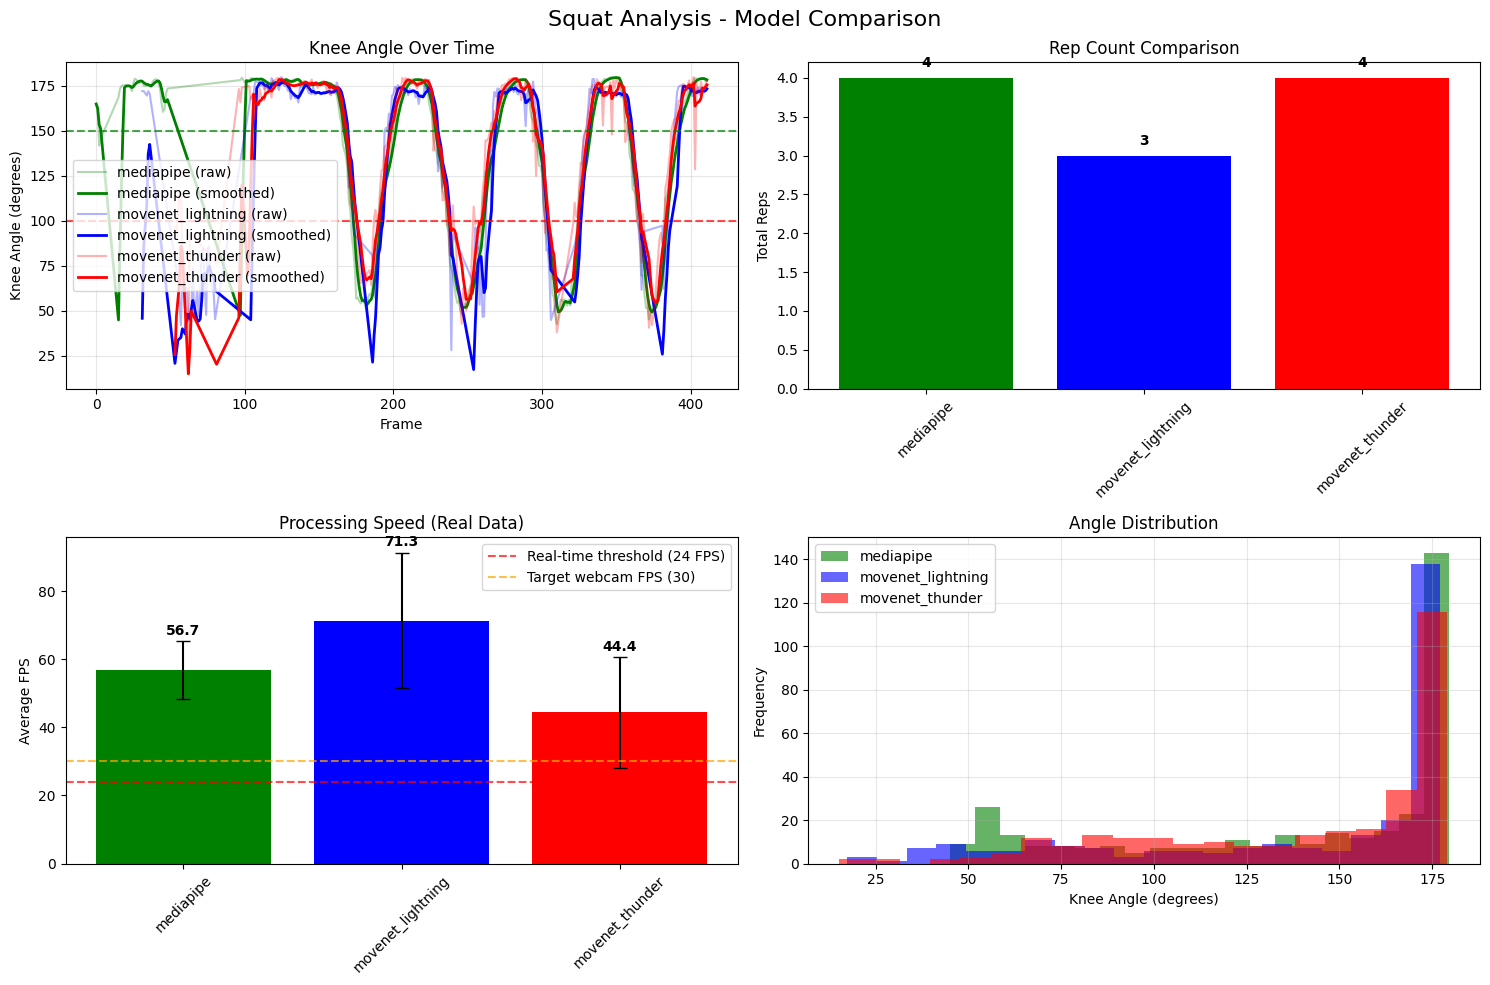

SQUAT ANALYSIS SUMMARY

MEDIAPIPE:
  Total reps: 4
  Average range of motion: 101.5°
  Consistency score: 98.5%
  Quality score: 94.8/100
  Performance:
    Average FPS: 56.7
    FPS Range: 25.4 - 66.5
    Avg Processing Time: 0.0181s
    Real-time capable: Yes
    FPS Stability: Low (σ=8.5)
  Angle Analysis:
    Range: 45.0° - 179.7° (ROM: 134.7°)
    Depth: ✓ Good squat depth achieved (min: 45.0°)
  Form Analysis:
    Form score: 26.6/100
    Total faults detected: 10

MOVENET_LIGHTNING:
  Total reps: 3
  Average range of motion: 139.0°
  Consistency score: 88.9%
  Quality score: 91.5/100
  Performance:
    Average FPS: 71.3
    FPS Range: 0.0 - 278.1
    Avg Processing Time: 0.0147s
    Real-time capable: Yes
    FPS Stability: Low (σ=19.9)
  Angle Analysis:
    Range: 17.4° - 177.2° (ROM: 159.8°)
    Depth: ✓ Good squat depth achieved (min: 17.4°)
  Form Analysis:
    Form score: 58.9/100
    Total faults detected: 5

MOVENET_THUNDER:
  Total reps: 4
  Average range of motion: 91.7

In [5]:
def plot_angle_comparison(tester):
    """Plot angle traces from all models with real performance data"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Squat Analysis - Model Comparison', fontsize=16)
    
    colors = {'mediapipe': 'green', 'movenet_lightning': 'blue', 'movenet_thunder': 'red'}
    
    # Plot 1: Angle traces
    ax1 = axes[0, 0]
    for model_name, history in tester.angle_history.items():
        if len(history) > 0:
            frames = [h['frame'] for h in history]
            angles = [h['angle'] for h in history]
            smoothed = [h['smoothed_angle'] for h in history]
            
            ax1.plot(frames, angles, color=colors[model_name], alpha=0.3, 
                    label=f'{model_name} (raw)')
            ax1.plot(frames, smoothed, color=colors[model_name], linewidth=2,
                    label=f'{model_name} (smoothed)')
    
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Knee Angle (degrees)')
    ax1.set_title('Knee Angle Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add threshold lines
    if 'mediapipe' in tester.rep_counters:
        config = tester.rep_counters['mediapipe'].exercise_configs['squat']
        ax1.axhline(y=config['down_threshold'], color='red', linestyle='--', alpha=0.7, label='Down threshold')
        ax1.axhline(y=config['up_threshold'], color='green', linestyle='--', alpha=0.7, label='Up threshold')
    
    # Plot 2: Rep counts comparison
    ax2 = axes[0, 1]
    models = list(tester.rep_counters.keys())
    rep_counts = [counter.rep_count for counter in tester.rep_counters.values()]
    bars = ax2.bar(models, rep_counts, color=[colors[m] for m in models])
    ax2.set_ylabel('Total Reps')
    ax2.set_title('Rep Count Comparison')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, count in zip(bars, rep_counts):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(count), ha='center', va='bottom', fontweight='bold')
    
    # Plot 3: Performance metrics (Real FPS data)
    ax3 = axes[1, 0]
    fps_values = []
    fps_ranges = []  # For error bars
    
    for model_name in models:
        if hasattr(tester, 'performance_stats') and model_name in tester.performance_stats:
            # Use real FPS data from performance tracking
            fps_data = tester.performance_stats[model_name]['fps_values']
            if len(fps_data) > 0:
                avg_fps = sum(fps_data) / len(fps_data)
                fps_std = (sum((x - avg_fps) ** 2 for x in fps_data) / len(fps_data)) ** 0.5
                fps_values.append(avg_fps)
                fps_ranges.append(fps_std)
            else:
                fps_values.append(0)
                fps_ranges.append(0)
        elif len(tester.angle_history[model_name]) > 0:
            # Fallback: calculate from angle history
            fps_data = [h.get('fps', 0) for h in tester.angle_history[model_name] if 'fps' in h]
            if len(fps_data) > 0:
                avg_fps = sum(fps_data) / len(fps_data)
                fps_std = (sum((x - avg_fps) ** 2 for x in fps_data) / len(fps_data)) ** 0.5
                fps_values.append(avg_fps)
                fps_ranges.append(fps_std)
            else:
                fps_values.append(0)
                fps_ranges.append(0)
        else:
            fps_values.append(0)
            fps_ranges.append(0)
    
    bars2 = ax3.bar(models, fps_values, yerr=fps_ranges, capsize=5, color=[colors[m] for m in models])
    ax3.set_ylabel('Average FPS')
    ax3.set_title('Processing Speed (Real Data)')
    ax3.tick_params(axis='x', rotation=45)
    ax3.axhline(y=24, color='red', linestyle='--', alpha=0.7, label='Real-time threshold (24 FPS)')
    ax3.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Target webcam FPS (30)')
    ax3.legend()
    
    # Add FPS value labels on bars
    for bar, fps, std in zip(bars2, fps_values, fps_ranges):
        if fps > 0:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 1,
                    f'{fps:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 4: Angle distribution
    ax4 = axes[1, 1]
    for model_name, history in tester.angle_history.items():
        if len(history) > 0:
            angles = [h['smoothed_angle'] for h in history]
            ax4.hist(angles, bins=20, alpha=0.6, label=model_name, color=colors[model_name])
    
    ax4.set_xlabel('Knee Angle (degrees)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Angle Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_squat_quality(tester):
    """Analyze squat quality metrics with performance data"""
    print("SQUAT ANALYSIS SUMMARY")
    print("=" * 50)
    
    for model_name, counter in tester.rep_counters.items():
        print(f"\n{model_name.upper()}:")
        
        # Get quality metrics
        quality_metrics = counter.get_rep_quality_metrics()
        
        print(f"  Total reps: {quality_metrics.get('total_reps', 0)}")
        print(f"  Average range of motion: {quality_metrics.get('avg_range_of_motion', 0):.1f}°")
        print(f"  Consistency score: {quality_metrics.get('range_consistency', 0)*100:.1f}%")
        print(f"  Quality score: {quality_metrics.get('quality_score', 0):.1f}/100")
        
        # Performance metrics
        if hasattr(tester, 'performance_stats') and model_name in tester.performance_stats:
            fps_data = tester.performance_stats[model_name]['fps_values']
            processing_data = tester.performance_stats[model_name]['processing_times']
            
            if len(fps_data) > 0:
                avg_fps = sum(fps_data) / len(fps_data)
                max_fps = max(fps_data)
                min_fps = min(fps_data)
                avg_processing_time = sum(processing_data) / len(processing_data)
                
                print(f"  Performance:")
                print(f"    Average FPS: {avg_fps:.1f}")
                print(f"    FPS Range: {min_fps:.1f} - {max_fps:.1f}")
                print(f"    Avg Processing Time: {avg_processing_time:.4f}s")
                print(f"    Real-time capable: {'Yes' if avg_fps >= 24 else 'No'}")
                
                # Stability assessment
                fps_std = (sum((x - avg_fps) ** 2 for x in fps_data) / len(fps_data)) ** 0.5
                stability = "High" if fps_std < 2 else "Medium" if fps_std < 5 else "Low"
                print(f"    FPS Stability: {stability} (σ={fps_std:.1f})")
        
        # Analyze angle range
        if len(tester.angle_history[model_name]) > 0:
            angles = [h['smoothed_angle'] for h in tester.angle_history[model_name]]
            min_angle = min(angles)
            max_angle = max(angles)
            range_of_motion = max_angle - min_angle
            
            print(f"  Angle Analysis:")
            print(f"    Range: {min_angle:.1f}° - {max_angle:.1f}° (ROM: {range_of_motion:.1f}°)")
            
            # Check squat depth
            if min_angle < 90:
                depth_assessment = f"✓ Good squat depth achieved (min: {min_angle:.1f}°)"
            elif min_angle < 100:
                depth_assessment = f"~ Moderate squat depth (min: {min_angle:.1f}°)"
            else:
                depth_assessment = f"✗ Insufficient squat depth (min: {min_angle:.1f}°)"
            
            print(f"    Depth: {depth_assessment}")

        # Form analysis summary
        form_summary = tester.form_analyzers[model_name].get_form_summary()
        print(f"  Form Analysis:")
        print(f"    Form score: {form_summary.get('form_score', 100):.1f}/100")
        print(f"    Total faults detected: {form_summary.get('total_faults', 0)}")

def create_performance_comparison_table(tester):
    """Create a detailed performance comparison table"""
    if not hasattr(tester, 'performance_stats'):
        print("No performance data available. Run the real-time test first!")
        return
    
    print("\nDETAILED PERFORMANCE COMPARISON")
    print("=" * 80)
    
    # Table header
    print(f"{'Model':<18} {'Avg FPS':<10} {'Min FPS':<10} {'Max FPS':<10} {'Proc Time':<12} {'Real-time':<10}")
    print("-" * 80)
    
    for model_name, stats in tester.performance_stats.items():
        if len(stats['fps_values']) > 0:
            avg_fps = sum(stats['fps_values']) / len(stats['fps_values'])
            min_fps = min(stats['fps_values'])
            max_fps = max(stats['fps_values'])
            avg_proc_time = sum(stats['processing_times']) / len(stats['processing_times'])
            realtime = "Yes" if avg_fps >= 24 else "No"
            
            print(f"{model_name:<18} {avg_fps:<10.1f} {min_fps:<10.1f} {max_fps:<10.1f} {avg_proc_time:<12.4f} {realtime:<10}")

# Run analysis if data is available
if any(len(history) > 0 for history in tester.angle_history.values()):
    plot_angle_comparison(tester)
    analyze_squat_quality(tester)
    create_performance_comparison_table(tester)
else:
    print("No data available. Run the real-time test first!")